<div align=center>

---
# Calibration
---

</div>


## Hooke & Jeeves

in order to get the best shifts to inject to optimize the component performances, I made a genetic algorithme that iteratively mutate a shifter and keep the mutation if it minimize the associated metric. All the shifters that act on the bright channel are associated with the bright metric that must be maximized

$$
M_B = |B|^2
$$

While the other shifters are associated with the kernel metric that must be minimized.

$$
M_K = \sum_{n=1}^3|K_n|
$$

Merging these two metrics can induce local minimum since improving the bright metric can deterior the kernel metric. This separation is then necessary to ensure reaching a global minimum (empirically demonstrated)

> **Acknowledgment**
> - Romain Laugier for the idea of merging the metrics

Performances in lab (Γ=0)
Achieved Kernel-Null depth:
   Mean: 1.63e-01 | 1.63e-01 | 1.63e-01
   Med:  1.63e-01 | 1.63e-01 | 1.63e-01
   Std:  6.21e-03 | 6.21e-03 | 6.21e-03

Performances in space (Γ=1 nm)
Achieved Kernel-Null depth:
   Mean: 1.64e-01 | 1.64e-01 | 1.64e-01
   Med:  1.64e-01 | 1.64e-01 | 1.64e-01
   Std:  5.70e-03 | 5.70e-03 | 5.70e-03

Performances in atmosphere (Γ=100 nm)
Achieved Kernel-Null depth:
   Mean: 1.17e-01 | 1.17e-01 | 1.17e-01
   Med:  1.47e-01 | 1.47e-01 | 1.47e-01
   Std:  1.67e-01 | 1.67e-01 | 1.67e-01
Performances in lab (Γ=0)
Achieved Kernel-Null depth:
   Mean: -1.39e-03 | -1.39e-03 | -1.39e-03
   Med:  -1.54e-03 | -1.54e-03 | -1.54e-03
   Std:  2.97e-03 | 2.97e-03 | 2.97e-03

Performances in space (Γ=1 nm)
Achieved Kernel-Null depth:
   Mean: -2.24e-03 | -2.24e-03 | -2.24e-03
   Med:  -2.22e-03 | -2.22e-03 | -2.22e-03
   Std:  3.44e-03 | 3.44e-03 | 3.44e-03

Performances in atmosphere (Γ=100 nm)
Achieved Kernel-Null depth:
   Mean: -9.47e-03 | -9.47

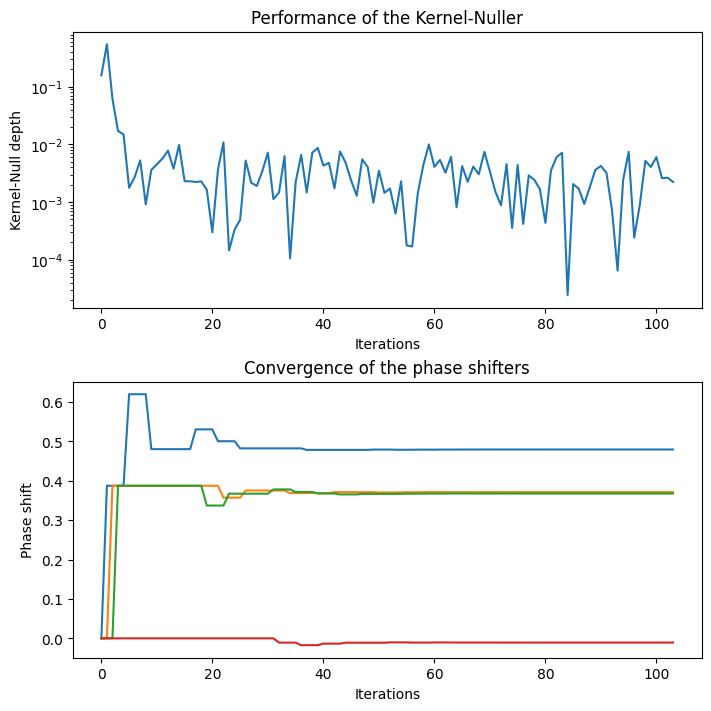

In [1]:
import calibration
import phise
import astropy.units as u
import numpy as np

ctx = phise.examples.contexts.get_PHOB()

_ = calibration.genetic_approach(ctx=ctx, β=0.6, verbose=False, figsize=(7,7), save_as="generated/thesis/calibration/trial_error.png")

[  7916.092  36947.092  36344.092 165887.092]
[0.23595873 0.86162991 0.59663756 0.29039712]


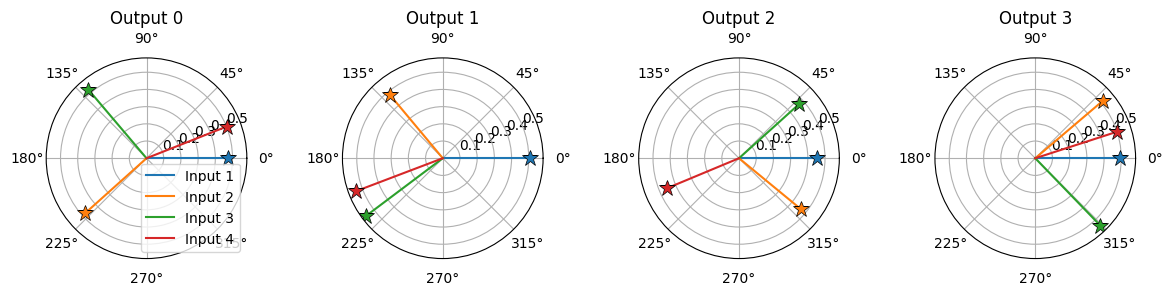

In [2]:
# Test

import phise
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

ctx = phise.examples.contexts.get_PHOB()

ctx.target.f *= 2

print(ctx.observe())
print(ctx.interferometer.chip.σ / ctx.interferometer.λ)

_ = ctx.interferometer.chip.laugiergram()

### Metric comparison

Which metric for the Hooke & Jeeves is the best to optimize the component performance?

In [3]:
from analysis.hooke_jeeves import metrics as hooke_jeeves_metrics
import phise
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy as copy

ctx = phise.examples.contexts.get_PHOB()
# ctx.camera.ideal = True
df, fig, fig2 = hooke_jeeves_metrics.compare(ctx, N = 10, demo=True)

ModuleNotFoundError: No module named 'analysis'

In [ ]:
from analysis.hooke_jeeves import metrics as hooke_jeeves_metrics
import phise
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy as copy

ctx = phise.examples.contexts.get_PHOB()
# ctx.camera.ideal = True
df, fig, fig2 = hooke_jeeves_metrics.compare(ctx, N = 100)
df

In [ ]:
from analysis.hooke_jeeves import metrics as hooke_jeeves_metrics
import phise
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy as copy

ctx = phise.examples.contexts.get_PHOB()
ctx.camera.ideal = True
df_ideal, fig_ideal, fig2_ideal = hooke_jeeves_metrics.compare(ctx, N = 200)
df_ideal

In [ ]:
from analysis.hooke_jeeves import metrics as hooke_jeeves_metrics
import phise
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy as copy

ctx = phise.examples.contexts.get_PHOB()
ctx.target.f *= 100
ctx.camera.ideal = True
df_ideal, fig_ideal = hooke_jeeves_metrics.compare(ctx, N = 200)
df_ideal

In [ ]:
from analysis.hooke_jeeves import metrics as hooke_jeeves_metrics
import phise
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy as copy

ctx = phise.examples.contexts.get_PHOB()
ctx.target.f *= 100
ctx.camera.ideal = False
df_ideal, fig_ideal = hooke_jeeves_metrics.compare(ctx, N = 200)
df_ideal

## Obstruction

En obstruant successivement une paire d'entrées, il est possible de simplifier le problème d'optimisation en ne jouant que sur un seul paramètre et en ne regardant qu'une seule sortie.

Il existe différentes façon de procéder. Je ne vais détailler ici que l'une d'entre elles.

On commence par obstruer les entrées $I_2$ et $I_3$. Au regard de l'architectue de notre composant, on peut alors décrire la fonction de transfert pour la sortie brillante $B$

$$
B = \left|\left(a_1 e^{i(\theta_1 + \sigma_1 + \phi_1)} + a_2 e^{i(\theta_2 + \sigma_2 + \phi_2)}\right) e^{i(\sigma_5 + \phi_5)}\right|^2
$$

Où $a_n$ et $\theta_n$ représentent respectivement l'amplitude et la phase des signaux d'entrée. $\sigma_n$ correspond à la perturbation de phase (inconnue) associé au retardateur $n$ et $\phi_n$ est la phase que l'on inject volontairement via le retardateur pour tenter de compenser cette perturbation.

La calibration se faisant en laboatoire, on peut supposer une intensité totale fixée à $1$ (unité arbitraire) et que chaque entrée reçoi le même flux soit $a_1 = a_2 = 1/\sqrt{2}$, et parfaitement cophasé, soit $\theta_1 = \theta_2 = \theta$. Etant donné que l'on a accès qu'a l'intensité du signal, nous sommes insensible à la phase globale, ce qui permet de simplifier l'équation précédente :

$$
B = \frac{1}{2} \left|e^{i(\sigma_1 + \phi_1)} + e^{i(\sigma_2 + \phi_2)}\right|^2
$$

En maximisant $B$, on devrait alors trouver $1$ ce qui implique que

$$
\sigma_1 + \phi_1 = \sigma_2 + \phi_2
$$

On peut utiliser $\phi_1$ comme référence (phase globale) et ainsi le fixer à 0, ce qui donne alors

$$
\phi_2 = \sigma_1 - \sigma_2
$$

On peut alors soit effectuer différentes mesures de $B$ à $\phi_2$ fixé et en déduire $\sigma_1$ et $\sigma_2$ par résolution d'un système déquation, soit trouver dichotomiquement la valeur de $\phi_2$ qui maximise $B$.

In [ ]:
import calibration
import phise
import astropy.units as u

ctx = phise.examples.contexts.get_VLTI()
ctx.monochromatic = True
_ = calibration.obstruction_approach(n=1000, ctx=ctx, figsize=(5,5), save_as="generated/thesis/calibration/obstruction.png")

## Comparison

In [ ]:
import calibration
calibration.compare_approaches(β=0.99, n=10_000, figsize=(3,3), save_as="generated/thesis/calibration/comparison.png")

### Comparison on a small component

In [ ]:
import phise
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy as copy

ctx = phise.examples.contexts.get_PHOB()
ctx.interferometer.chip = phise.N4x4_D8(
                φ = np.zeros(8) * ctx.interferometer.λ, # Injected phase shifts
                σ = np.random.rand(8) * ctx.interferometer.λ, # Manufacturing OPD errors
                λ0 = ctx.interferometer.λ,
                name = "N4x4-D8", # Kernel nuller name
            )

ctx.target.f *= 10
ctx.interferometer.camera.ideal = True

ctx1 = copy(ctx)
ctx2 = copy(ctx)

_ = ctx1.interferometer.chip.laugiergram()
ctx1.interferometer.chip.calibrate(method="Hooke&Jeeves", plot=True)
_= ctx1.interferometer.chip.laugiergram()
plt.show()
outs1 = ctx1.observe()
print(outs1[1:] / outs1[0])
ctx2.interferometer.chip.calibrate(method="obstruction", plot=True)
_= ctx2.interferometer.chip.laugiergram()
plt.show()
outs2 = ctx2.observe()
print(outs2[1:] / outs2[0])